<a href="https://colab.research.google.com/github/Shalini-K-10/user-authentication-system/blob/main/Pothole_Detection_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pothole Detection and Road Condition Classification
**Deep Learning Task:** Object Detection + Classification

**Pipeline:** Download dataset → Train YOLOv8 → Evaluate → Classify road condition → Test on new images

Run each cell in order (Shift+Enter). Make sure GPU is enabled: **Runtime → Change runtime type → GPU (T4)**

## Step 1: Verify GPU

In [ ]:
!nvidia-smi

Fri Aug  7 19:04:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

You should see a **Tesla T4** listed. If you see an error instead, go to Runtime → Change runtime type → select GPU, then re-run this cell.

## Step 2: Install Required Libraries

In [ ]:
!pip install -q ultralytics roboflow opencv-python matplotlib

import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from roboflow import Roboflow

print('Libraries installed successfully.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Libraries installed successfully.


## Step 3: Download Pothole Dataset from Roboflow

1. Go to https://universe.roboflow.com and search **"pothole detection"**
2. Pick a dataset (look for one with a good number of images, YOLOv8 export format available)
3. Click **Download this Dataset → YOLOv8 format → show download code**
4. Copy the `rf.workspace(...).project(...)` and `version(...)` lines it gives you and paste them below, replacing the placeholders.

You do NOT need to sign up for a paid plan — the free tier is enough for this project.

In [ ]:
!pip install roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="2ERE2NwzyWC7KeETSukQ")
project = rf.workspace("matt-s1uw6").project("pothole-detection-yolov8-ehkp9")
version = project.version(1)
dataset = version.download("yolov8")

print('Dataset downloaded to:', dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Pothole-Detection-YOLOv8-1 in yolov8:: 100%|██████████| 3138/3138 [00:00<00:00, 6190.29it/s]

Dataset downloaded to: /content/Pothole-Detection-YOLOv8-1


## Step 4: Explore the Dataset

Number of training images: 1363


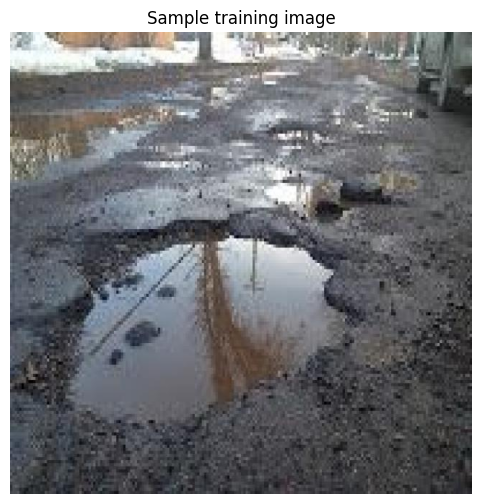

In [ ]:
train_images_path = f"{dataset.location}/train/images"
image_files = os.listdir(train_images_path)
print(f'Number of training images: {len(image_files)}')

# Show a sample image
sample_img = cv2.imread(os.path.join(train_images_path, image_files[0]))
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6,6))
plt.imshow(sample_img)
plt.title('Sample training image')
plt.axis('off')
plt.show()

## Step 5: Train YOLOv8 on the Pothole Dataset

We use `yolov8n.pt` (the smallest/nano version) — it trains faster and is enough for this project. 30-50 epochs is a reasonable range; start with 30 if you're short on time.

In [ ]:
model = YOLO('yolov8n.pt')

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    name='pothole_run',
    project='pothole_training',
    verbose=True
)

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Pothole-Detection-YOLOv8-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pothole_run, nbs

## Step 6: Evaluate the Trained Model

In [ ]:
metrics = model.val()

print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1883.8±1287.0 MB/s, size: 77.3 KB)
val: Scanning /content/Pothole-Detection-YOLOv8-1/valid/labels.cache... 131 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 131/131 50.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.9it/s 4.8s
                   all        131       1025      0.677      0.596      0.649        0.3
Speed: 5.0ms preprocess, 6.1ms inference, 0.0ms loss, 5.7ms postprocess per image
Results saved to /content/runs/detect/val
Precision: 0.6772
Recall: 0.5961
mAP50: 0.6494
mAP50-95: 0.2997


## Step 7: Run Detection on a Test Image


image 1/1 /content/Pothole-Detection-YOLOv8-1/test/images/72_jpg.rf.70f2f6209bdb2fdca7bc97fc1b54ee1b.jpg: 640x640 3 potholess, 7.2ms
Speed: 1.7ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


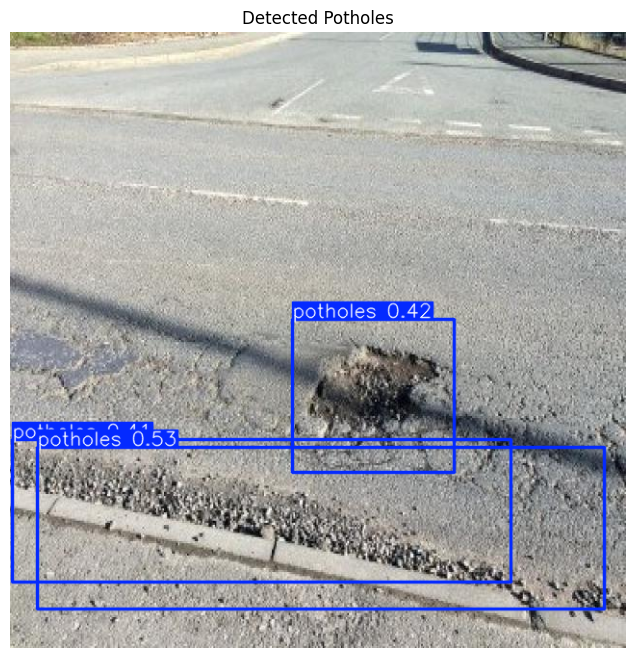

In [ ]:
test_images_path = f"{dataset.location}/test/images"
test_files = os.listdir(test_images_path)
test_img_path = os.path.join(test_images_path, test_files[0])

prediction_results = model.predict(source=test_img_path, conf=0.4, save=True)

# Display the result with bounding boxes drawn
result_img = prediction_results[0].plot()
result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,8))
plt.imshow(result_img)
plt.title('Detected Potholes')
plt.axis('off')
plt.show()

## Step 8: Road Condition Classification Logic

Simple rule-based logic on top of the detection results — no second model needed. Thresholds are adjustable based on what looks reasonable during testing.

In [ ]:
def classify_road_condition(num_potholes):
    """
    Classifies road condition based on number of detected potholes.
    Adjust thresholds as needed based on your dataset/testing.
    """
    if num_potholes == 0:
        return "Good"
    elif 1 <= num_potholes <= 2:
        return "Damaged"
    else:
        return "Severely Damaged"

# Count potholes detected in the test image from Step 7
num_detected = len(prediction_results[0].boxes)
condition = classify_road_condition(num_detected)

print(f"Potholes detected: {num_detected}")
print(f"Road Condition: {condition}")

Potholes detected: 3
Road Condition: Severely Damaged


## Step 9: Test on Your Own Uploaded Photo

Run this cell, click 'Choose Files', and upload any road photo (e.g. from your phone) to test the full pipeline end-to-end.

Saving WhatsApp Image 2026-08-04 at 2.20.18 PM.jpeg to WhatsApp Image 2026-08-04 at 2.20.18 PM.jpeg

image 1/1 /content/WhatsApp Image 2026-08-04 at 2.20.18 PM.jpeg: 384x640 10 potholess, 44.9ms
Speed: 2.8ms preprocess, 44.9ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict


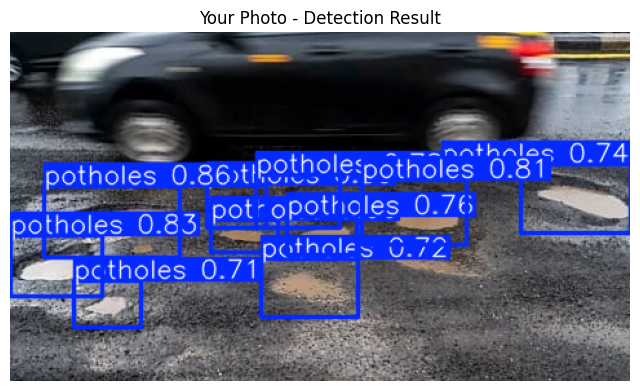

Potholes detected: 10
Road Condition: Severely Damaged


In [ ]:
from google.colab import files

uploaded = files.upload()
uploaded_filename = list(uploaded.keys())[0]

my_results = model.predict(source=uploaded_filename, conf=0.4, save=True)

result_img = my_results[0].plot()
result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,8))
plt.imshow(result_img)
plt.title('Your Photo - Detection Result')
plt.axis('off')
plt.show()

num_detected = len(my_results[0].boxes)
condition = classify_road_condition(num_detected)
print(f"Potholes detected: {num_detected}")
print(f"Road Condition: {condition}")

## Step 10: Launch a Simple Web App (Gradio)

This creates a simple, clean web interface for your project — upload a photo, see the detection and road condition result. It runs directly here in Colab and gives you a public link you can open in any browser or show during your demo.

In [1]:
!pip install -q gradio
import gradio as gr

def classify_road_condition_app(num_potholes):
    if num_potholes == 0:
        return "Good", "#22c55e", "🟢"
    elif 1 <= num_potholes <= 2:
        return "Damaged", "#f59e0b", "🟠"
    else:
        return "Severely Damaged", "#ef4444", "🔴"

def detect_potholes_app(image):
    if image is None:
        return None, gr.update(value="Upload a road photo to begin.", visible=True), "", gr.update(visible=False)
    results = model.predict(source=image, conf=0.4, save=False)
    annotated_image = results[0].plot()
    num_detected = len(results[0].boxes)
    condition, color, icon = classify_road_condition_app(num_detected)

    result_html = f"""
    <div style='background:{color}22; border:2px solid {color}; border-radius:14px; padding:18px; text-align:center;'>
        <div style='font-size:38px;'>{icon}</div>
        <div style='font-size:22px; font-weight:700; color:{color}; margin-top:4px;'>{condition}</div>
    </div>
    <div style='display:flex; gap:12px; margin-top:14px;'>
        <div style='flex:1; background:#1f2937; border-radius:12px; padding:14px; text-align:center;'>
            <div style='color:#9ca3af; font-size:13px;'>POTHOLES DETECTED</div>
            <div style='color:#fff; font-size:26px; font-weight:700;'>{num_detected}</div>
        </div>
    </div>
    """
    return annotated_image, gr.update(value=result_html, visible=True), condition, gr.update(visible=True)

def submit_report(condition):
    if not condition:
        return "Please run a detection first."
    return f"✅ Report submitted to the Transportation Department — Status: **{condition}**"

custom_css = """
.gradio-container {
    background:
        linear-gradient(rgba(10,15,25,0.82), rgba(10,15,25,0.88)),
        url('https://images.unsplash.com/photo-1515162816999-a0c47dc192f7?auto=format&fit=crop&w=1600&q=80') !important;
    background-size: cover !important;
    background-position: center !important;
    background-attachment: fixed !important;
}
#title { text-align:center; color:#f8fafc; font-size:34px; font-weight:800; margin-bottom:0px; }
#subtitle { text-align:center; color:#94a3b8; margin-top:4px; margin-bottom:20px; font-size:15px; }
.panel { background:#111827cc; border-radius:16px; padding:16px; border:1px solid #334155; }
footer { display:none !important; }
"""

with gr.Blocks(theme=gr.themes.Soft(primary_hue="orange", neutral_hue="slate"), css=custom_css) as demo:
    gr.Markdown("🛣️ Pothole Detector", elem_id="title")
    gr.Markdown("AI-Based Pothole Detection & Road Condition Classification", elem_id="subtitle")

    with gr.Row():
        with gr.Column(elem_classes="panel"):
            gr.Markdown("### 📷 Upload")
            input_image = gr.Image(type="numpy", label="Road Photo")
            detect_btn = gr.Button("🔍 Detect Potholes", variant="primary", size="lg")
        with gr.Column(elem_classes="panel"):
            gr.Markdown("### 📍 Detection Result")
            output_image = gr.Image(type="numpy", label="Bounding Boxes")
            result_html = gr.HTML("Upload a photo and click 'Detect Potholes' to see results.")
            condition_state = gr.State("")
            submit_btn = gr.Button("📄 Submit Report to Transportation Department", visible=False)
            submit_status = gr.Markdown("")

    detect_btn.click(
        fn=detect_potholes_app,
        inputs=input_image,
        outputs=[output_image, result_html, condition_state, submit_btn]
    )
    submit_btn.click(fn=submit_report, inputs=condition_state, outputs=submit_status)

demo.launch(share=True)  # gives you a public link to open/demo in any browser

/tmp/ipykernel_2032/2379003858.py:54: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="orange", neutral_hue="slate"), css=custom_css) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://901ebc6de3b23639d1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Step 11: Save Results for Your Report

Save a few example output images (with bounding boxes) to reference in your report/demo. These are automatically saved by `save=True` in the predict calls above — find them in the `runs/detect/predict*` folder in the Colab file browser (left sidebar).

In [ ]:
print("Training metrics:")
print(f"  Precision: {metrics.box.mp:.4f}")
print(f"  Recall: {metrics.box.mr:.4f}")
print(f"  mAP50: {metrics.box.map50:.4f}")
print(f"  mAP50-95: {metrics.box.map:.4f}")
print()
print("Example outputs are saved under: runs/detect/predict*/ (check left sidebar file browser)")
print("Take screenshots of a few results (bounding boxes + your printed condition label) for your report.")

Training metrics:
  Precision: 0.6772
  Recall: 0.5961
  mAP50: 0.6494
  mAP50-95: 0.2997

Example outputs are saved under: runs/detect/predict*/ (check left sidebar file browser)
Take screenshots of a few results (bounding boxes + your printed condition label) for your report.
